# Chapter 3 Figures

## Kernel-Weight Method — Data Pooling Visualization

Shows all angular distribution datasets contributing to a single energy bin
on the pipeline's union grid. Visual encoding:
- **Marker shape** = experiment
- **Color** = CDF overlap weight (continuous colormap + colorbar)
- **Black edge** = deduplicated point (closest energy to bin center per experiment)

In [6]:
from __future__ import annotations

import sys
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.stats import norm

# Ensure kika is importable
REPO_ROOT = Path("/home/MONLEON-JUAN/kika")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from kika.exfor import read_all_exfor

# ── Inline pipeline functions ──────────────────────────────────────────

def compute_overlap_weight(exp_energy_mev, sigma_E_mev, bin_lower_mev, bin_upper_mev):
    """CDF-based overlap weight: P(true energy in bin).  (exfor_utils.py:439-489)"""
    if sigma_E_mev <= 0:
        return 1.0 if bin_lower_mev <= exp_energy_mev <= bin_upper_mev else 0.0
    z_high = (bin_upper_mev - exp_energy_mev) / sigma_E_mev
    z_low = (bin_lower_mev - exp_energy_mev) / sigma_E_mev
    return norm.cdf(z_high) - norm.cdf(z_low)

# TOF sigma_E (tof_parameters.py:163-217)
NEUTRON_MASS_MEV = 939.565378
SPEED_OF_LIGHT_M_NS = 0.299792458

def compute_sigma_E(energy_mev, flight_path_m, time_resolution_ns, min_sigma_E_kev=1.0):
    """Compute energy resolution sigma_E from TOF parameters."""
    if energy_mev <= 0:
        return min_sigma_E_kev / 1000.0
    velocity_m_ns = SPEED_OF_LIGHT_M_NS * np.sqrt(2.0 * energy_mev / NEUTRON_MASS_MEV)
    flight_time_ns = flight_path_m / velocity_m_ns
    sigma_E_mev = energy_mev * 2.0 * (time_resolution_ns / flight_time_ns)
    return max(sigma_E_mev, min_sigma_E_kev / 1000.0)

# ── Constants ──────────────────────────────────────────────────────────

MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CMAP = plt.cm.plasma
OUTPUT_DIR = Path("/share_snc/snc/JuanMonleon/EXFOR/figures/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXFOR_JSON_DIR = "/share_snc/snc/JuanMonleon/EXFOR/data_v1/"
TOF_FILE = Path("/share_snc/snc/JuanMonleon/EXFOR/exfor_tof_parameters.json")

# Pipeline grid config (exfor_to_endf_sampling_v2.py:378-383)
UNION_GRID_SUBENTRIES = [
    ("10571002", 0.847, 2.5),   # Kinney
    ("10886002", 2.5, 4.0),     # Smith
]
ENERGY_MIN, ENERGY_MAX = 0.847, 4.0
EXCLUDED = {"32246002"}
MIN_WEIGHT = 1e-3

# Default TOF params (ORELA-like)
DEFAULT_L = 27.037
DEFAULT_DT = 5.0

# Manuscript figure style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

## 1. Load EXFOR data and TOF parameters

In [7]:
# Load all EXFOR angular distribution data from curated JSON files
exfor_dict = read_all_exfor(
    source="json",
    directory=EXFOR_JSON_DIR,
    group_by_energy=False,
)
exfor_objects = list(exfor_dict.values())
print(f"Loaded {len(exfor_objects)} EXFOR datasets")

# Build label lookup and TOF params per experiment
label_map = {}   # exp_id -> "Author et al. (Year)"
tof_map = {}     # subentry_id -> (flight_path_m, time_resolution_ns)

with open(TOF_FILE) as f:
    tof_raw = json.load(f)

for obj in exfor_objects:
    # obj.subentry is already the full ID like "10571002"
    subentry_id = obj.subentry
    exp_id = f"{obj.entry}.{subentry_id}"
    label_map[exp_id] = obj.label

    if subentry_id not in tof_map:
        entry_data = tof_raw.get(subentry_id, {})
        eri = entry_data.get("energy_resolution_input") or entry_data.get("energy_resolution_inputs") or {}
        L = eri.get("distance", {}).get("value")
        dt = eri.get("time_resolution", {}).get("value")
        tof_map[subentry_id] = (
            float(L) if L is not None else DEFAULT_L,
            float(dt) if dt is not None else DEFAULT_DT,
        )

# Build the energy -> datasets cache from ExforAngularDistribution objects
exfor_cache = defaultdict(list)  # energy_mev -> [dataset_dict, ...]

for obj in exfor_objects:
    subentry_id = obj.subentry
    if subentry_id in EXCLUDED:
        continue
    exp_id = f"{obj.entry}.{subentry_id}"
    for energy_mev in obj.energies(unit="MeV"):
        df = obj.to_dataframe(
            energy=energy_mev, energy_unit="MeV",
            cross_section_unit="b/sr", angle_unit="deg",
            tolerance=1e-4,
        )
        if df.empty:
            continue
        exfor_cache[energy_mev].append({
            "exp_id": exp_id,
            "subentry_id": subentry_id,
            "angle": df["angle"].values,
            "dsig": df["value"].values,
            "error": df["error"].values,
            "frame": obj.angle_frame,
        })

sorted_energies = sorted(exfor_cache.keys())
print(f"Cache: {len(sorted_energies)} unique energies "
      f"[{sorted_energies[0]:.4f}, {sorted_energies[-1]:.4f}] MeV")
print(f"TOF params for {len(tof_map)} experiments")

Loaded 14 EXFOR datasets
Cache: 16764 unique energies [0.4889, 7.9600] MeV
TOF params for 14 experiments


## 2. Build union energy grid and bin boundaries (pipeline-equivalent)

In [8]:
# Replicate build_union_energy_grid() (exfor_utils.py:620-687)
# Union grid: Kinney energies in [0.847, 2.5] + Smith energies in [2.5, 4.0]
union_energies = set()
for energy_mev, entries in exfor_cache.items():
    for ds in entries:
        sid = ds["subentry_id"]
        for sub_id, lo, hi in UNION_GRID_SUBENTRIES:
            if sid == sub_id and lo <= energy_mev <= hi:
                union_energies.add(energy_mev)

union_energies.update([ENERGY_MIN, ENERGY_MAX])
grid = np.array(sorted(union_energies))
print(f"Union grid: {len(grid)} points [{grid[0]:.4f}, {grid[-1]:.4f}] MeV")

# Replicate compute_energy_bins_with_tof_resolution() bin boundaries
# (exfor_utils.py:560-602): midpoints between consecutive grid points
bin_boundaries = []  # list of (energy, lo, hi)
n = len(grid)
for i, e in enumerate(grid):
    if i == 0:
        if n > 1:
            half_width = (grid[1] - e) / 2.0
            lo = max(0.0, e - half_width)
        else:
            lo = 0.0
    else:
        lo = (grid[i - 1] + e) / 2.0

    if i == n - 1:
        hi = e + (e - lo)
    else:
        hi = (e + grid[i + 1]) / 2.0

    bin_boundaries.append((e, lo, hi))

print(f"Bin boundaries computed for {len(bin_boundaries)} bins")
# Show a few examples
for idx in [0, 1, len(bin_boundaries) // 2, -1]:
    e, lo, hi = bin_boundaries[idx]
    print(f"  [{idx:4d}] E={e:.4f} MeV  bin=[{lo:.4f}, {hi:.4f}]")

Union grid: 1683 points [0.8470, 4.0000] MeV
Bin boundaries computed for 1683 bins
  [   0] E=0.8470 MeV  bin=[0.8465, 0.8475]
  [   1] E=0.8480 MeV  bin=[0.8475, 0.8485]
  [ 841] E=1.6880 MeV  bin=[1.6875, 1.6885]
  [  -1] E=4.0000 MeV  bin=[3.9525, 4.0475]


## 3. Select energy bin and compute pipeline-equivalent overlap weights

In [12]:
TARGET_ENERGY_MEV = 1.8

# Find closest grid point
idx = np.argmin(np.abs(grid - TARGET_ENERGY_MEV))
bin_energy, bin_lo, bin_hi = bin_boundaries[idx]
print(f"Target: {TARGET_ENERGY_MEV} MeV -> grid point {idx}: "
      f"E={bin_energy:.4f} MeV, bin=[{bin_lo:.4f}, {bin_hi:.4f}]")

# ── Collect ALL datasets with CDF overlap weight (pipeline lines 1654-1665) ──
raw_datasets = []
for energy_mev, entries in exfor_cache.items():
    for ds in entries:
        L, dt = tof_map[ds["subentry_id"]]
        sigma_E = compute_sigma_E(energy_mev, L, dt)
        w = compute_overlap_weight(energy_mev, sigma_E, bin_lo, bin_hi)
        if w >= MIN_WEIGHT:
            raw_datasets.append({**ds, "energy_mev": energy_mev, "weight": w})

print(f"Raw datasets with w >= {MIN_WEIGHT}: {len(raw_datasets)}")

# ── Experiment-level renormalization (pipeline lines 1667-1683) ──
exp_groups = defaultdict(list)
for i, ds in enumerate(raw_datasets):
    exp_groups[ds["exp_id"]].append(i)

datasets = []
for exp_id, indices in exp_groups.items():
    weights = [raw_datasets[i]["weight"] for i in indices]
    max_w = max(weights)
    sum_w = sum(weights)
    scale = max_w / sum_w  # shrink so total = max_w
    for i in indices:
        ds = dict(raw_datasets[i])
        ds["weight"] = ds["weight"] * scale
        datasets.append(ds)

# ── Deduplication marking: per experiment, closest energy to bin center ──
exp_dedup = defaultdict(list)
for i, ds in enumerate(datasets):
    exp_dedup[ds["exp_id"]].append(i)

for exp_id, indices in exp_dedup.items():
    # Find dataset closest to bin_energy
    best_idx = min(indices, key=lambda i: abs(datasets[i]["energy_mev"] - bin_energy))
    for i in indices:
        datasets[i]["is_deduped"] = (i == best_idx)

# Summary
exp_ids = sorted(set(d["exp_id"] for d in datasets))
print(f"\n{len(exp_ids)} experiments, {len(datasets)} datasets after renormalization:")
for eid in exp_ids:
    ds_list = [d for d in datasets if d["exp_id"] == eid]
    ws = [d["weight"] for d in ds_list]
    deduped = sum(1 for d in ds_list if d["is_deduped"])
    energies = sorted(d["energy_mev"] for d in ds_list)
    print(f"  {label_map.get(eid, eid):30s}  n={len(ds_list):3d}  "
          f"dedup={deduped}  w=[{min(ws):.4f}, {max(ws):.4f}]  "
          f"E=[{energies[0]:.3f}, {energies[-1]:.3f}]")

Target: 1.8 MeV -> grid point 953: E=1.8000 MeV, bin=[1.7995, 1.8005]
Raw datasets with w >= 0.001: 180

6 experiments, 180 datasets after renormalization:
  Kinney et al. (1976)            n= 69  dedup=1  w=[0.0000, 0.0009]  E=[1.767, 1.835]
  Smith et al. (1980)             n=  2  dedup=1  w=[0.0039, 0.0071]  E=[1.782, 1.823]
  Ramirez et al. (2017)           n=  1  dedup=1  w=[0.0239, 0.0239]  E=[1.800, 1.800]
  Cierjacks et al. (1978)         n=105  dedup=1  w=[0.0000, 0.0014]  E=[1.782, 1.819]
  Gkatis et al. (2025)            n=  2  dedup=1  w=[0.0093, 0.0156]  E=[1.791, 1.815]
  Morozov et al. (1972)           n=  1  dedup=1  w=[0.0323, 0.0323]  E=[1.800, 1.800]


## 4. Plot: KW data pool with colormap + marker shapes

Weight range: [0.000023, 0.032283]


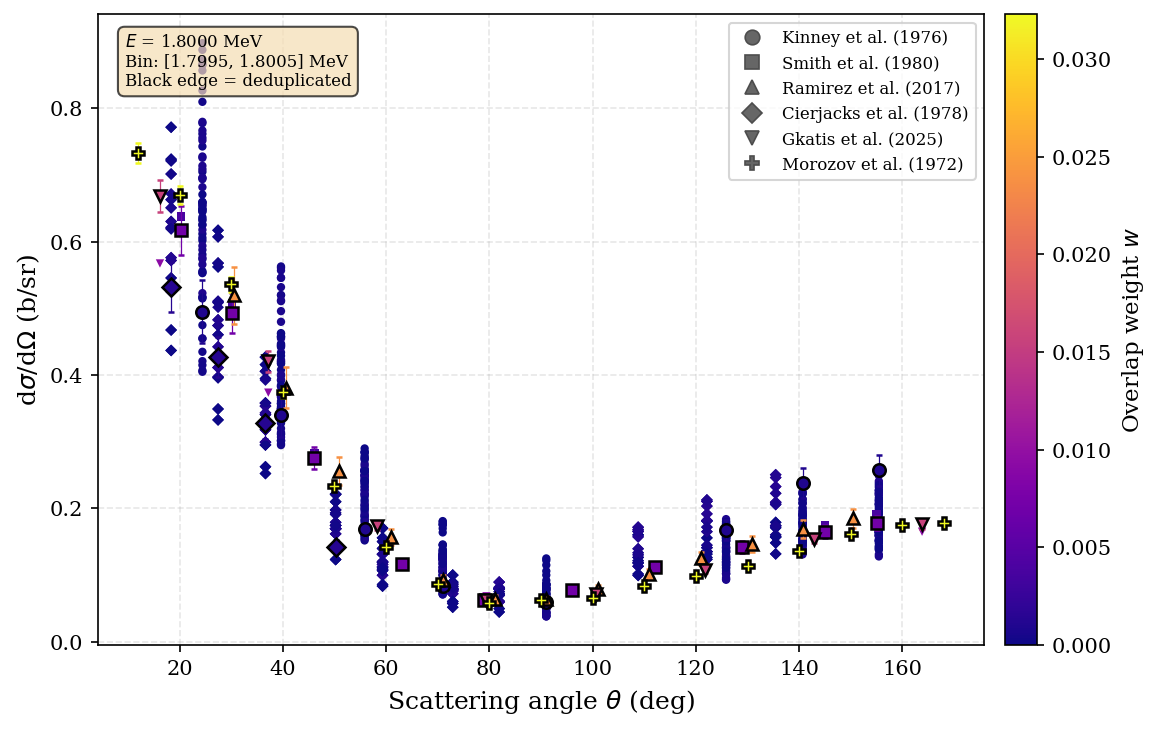

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

# Colormap normalization: use actual weight range for visible gradient
all_weights = [d["weight"] for d in datasets]
w_norm = mcolors.Normalize(vmin=0, vmax=max(all_weights))
sm = cm.ScalarMappable(cmap=CMAP, norm=w_norm)
sm.set_array([])
print(f"Weight range: [{min(all_weights):.6f}, {max(all_weights):.6f}]")

# Assign one marker shape per experiment
exp_marker = {eid: MARKERS[i % len(MARKERS)] for i, eid in enumerate(exp_ids)}

# ── Batch scatter by (experiment, is_deduped) for speed ──
for eid in exp_ids:
    marker = exp_marker[eid]
    ds_list = [d for d in datasets if d["exp_id"] == eid]

    # Non-deduplicated points: scatter (fast, no error bars)
    non_dedup = [d for d in ds_list if not d["is_deduped"]]
    if non_dedup:
        angles = np.concatenate([d["angle"] for d in non_dedup])
        values = np.concatenate([d["dsig"] for d in non_dedup])
        colors = np.concatenate([
            np.full(len(d["angle"]), d["weight"]) for d in non_dedup
        ])
        ax.scatter(
            angles, values,
            c=CMAP(w_norm(colors)),
            marker=marker, s=16,
            edgecolors="none", linewidths=0.3,
            zorder=2,
        )

    # Deduplicated point: errorbar with black edge (one per experiment)
    dedup = [d for d in ds_list if d["is_deduped"]]
    for d in dedup:
        color = CMAP(w_norm(d["weight"]))
        ax.errorbar(
            d["angle"], d["dsig"],
            yerr=d["error"],
            fmt=marker,
            color=color,
            markeredgecolor="black",
            markeredgewidth=1.2,
            markersize=6.0,
            capsize=1.5, capthick=0.6, elinewidth=0.6,
            ecolor=color,
            zorder=4,
            label="_nolegend_",
        )

# Colorbar
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Overlap weight $w$", fontsize=11)

# Custom legend: one entry per experiment with marker shape, neutral color
legend_handles = []
for eid in exp_ids:
    marker = exp_marker[eid]
    label = label_map.get(eid, eid)
    handle = Line2D(
        [0], [0], marker=marker, color="none",
        markerfacecolor="0.4", markeredgecolor="0.3",
        markersize=7, markeredgewidth=0.8, label=label,
    )
    legend_handles.append(handle)

ax.legend(handles=legend_handles, loc="upper right", frameon=True,
          fancybox=True, fontsize=8, ncol=1)

ax.set_xlabel(r"Scattering angle $\theta$ (deg)")
ax.set_ylabel(r"d$\sigma$/d$\Omega$ (b/sr)")

# Text box with bin info
textstr = (f"$E$ = {bin_energy:.4f} MeV\n"
           f"Bin: [{bin_lo:.4f}, {bin_hi:.4f}] MeV\n"
           f"Black edge = deduplicated")
props = dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.7)
ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment="top", horizontalalignment="left", bbox=props)

plt.tight_layout()
plt.show()

In [14]:
#out_path = OUTPUT_DIR / f"kw_data_pool_{bin_energy:.3f}MeV.png"
#fig.savefig(out_path, bbox_inches="tight", dpi=300)
#print(f"Saved: {out_path}")

KeyboardInterrupt: 